In [21]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')

print("Загрузка данных...")

# Динамическое определение корня проекта
project_root = Path.cwd()
if not (project_root / "datasets").exists() and (project_root.parent / "datasets").exists():
    project_root = project_root.parent

# Поиск файла данных
data_candidates = [
    project_root / "datasets" / "short_my_clean_3_with_weather.parquet"
]

data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Критическая ошибка: не найден базовый файл данных в папке datasets!")

df = pd.read_parquet(data_path)

if 'speed_mph' not in df.columns:
    required_speed_columns = {'trip_distance', 'duration_min'}
    if required_speed_columns.issubset(df.columns):
        duration_hours = df['duration_min'] / 60
        df['speed_mph'] = np.where(duration_hours > 0, df['trip_distance'] / duration_hours, np.nan)
        print("Колонка speed_mph не найдена, поэтому она рассчитана по расстоянию и длительности поездки.")
    else:
        print("Предупреждение: колонка speed_mph не найдена, а расстояния или длительности недостаточно для расчета скорости.")

# Русские названия используются только при выводе, внутренние имена колонок остаются стабильными.
RUSSIAN_COLUMNS = {
    "LocationID": "ID района",
    "PULocationID": "район отправления",
    "DOLocationID": "район назначения",
    "in_flow": "входящий поток",
    "out_flow": "исходящий поток",
    "in_degree": "входящая связность",
    "out_degree": "исходящая связность",
    "pagerank": "центральность PageRank",
    "total_flow": "общий поток",
    "flow_balance": "баланс потока",
    "route_trips": "поездки маршрута",
    "route_avg_revenue": "средняя выручка маршрута",
    "route_avg_duration": "средняя длительность маршрута",
    "route_avg_speed": "средняя скорость маршрута",
    "route_revenue_per_minute": "выручка в минуту",
    "route_revenue_per_mile": "выручка за милю",
    "component_id": "компонент",
    "zones": "количество районов",
    "top_zones": "основные районы",
    "component_total_flow": "общий поток компонента",
    "pickup_component": "компонент отправления",
    "dropoff_component": "компонент назначения",
    "trips": "поездки",
    "routes": "маршруты",
    "avg_revenue": "средняя выручка",
}

def display_ru(table, columns=RUSSIAN_COLUMNS):
    display(table.rename(columns=columns))

# Отображаем путь относительно корня репозитория
relative_data_path = data_path.relative_to(project_root)
print(f"Успешно загружен файл: {relative_data_path}")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")


Загрузка данных...
Колонка speed_mph не найдена, поэтому она рассчитана по расстоянию и длительности поездки.
Успешно загружен файл: datasets\short_my_clean_3_with_weather.parquet
Размер датасета: 100000 строк, 35 колонок


In [22]:
print("1. Агрегация маршрутов (признаки ребер)...")

# Базовая агрегация: используем только колонки, которые есть в датасете.
agg_dict = {
    'route_trips': ('total_amount', 'size'),
    'route_avg_revenue': ('total_amount', 'mean'),
    'route_avg_duration': ('duration_min', 'mean'),
    'total_revenue': ('total_amount', 'sum'),
    'total_distance': ('trip_distance', 'sum'),
    'total_time': ('duration_min', 'sum'),
}

if 'speed_mph' in df.columns:
    agg_dict['route_avg_speed'] = ('speed_mph', 'mean')
else:
    print("Предупреждение: колонка 'speed_mph' не найдена в датасете. Средняя скорость будет пустой.")

route_stats = df.groupby(['PULocationID', 'DOLocationID'], observed=False).agg(**agg_dict).reset_index()
if 'route_avg_speed' not in route_stats.columns:
    route_stats['route_avg_speed'] = np.nan

# Вычисляем производные метрики доходности маршрута
route_stats['route_revenue_per_minute'] = route_stats['total_revenue'] / (route_stats['total_time'] + 0.001)
route_stats['route_revenue_per_mile'] = route_stats['total_revenue'] / (route_stats['total_distance'] + 0.001)

# Удаляем временные колонки
route_stats = route_stats.drop(columns=['total_revenue', 'total_distance', 'total_time'])

# Исключаем локальные поездки внутри одного района для чистоты графа транзитных потоков
transit_routes = route_stats[route_stats['PULocationID'] != route_stats['DOLocationID']].copy()

print(f"Агрегация завершена. Получено {route_stats.shape[0]} уникальных маршрутов.")
print(f"Найдено уникальных транзитных маршрутов: {len(transit_routes)}")
display_ru(route_stats.head())


1. Агрегация маршрутов (признаки ребер)...
Агрегация завершена. Получено 6535 уникальных маршрутов.
Найдено уникальных транзитных маршрутов: 6436


,район отправления,район назначения,поездки маршрута,средняя выручка маршрута,средняя длительность маршрута,средняя скорость маршрута,выручка в минуту,выручка за милю
0,3,126,1,26.00,18.583333,21.632287,1.399028,3.880018
1,3,159,1,33.00,39.216667,11.015725,0.841458,4.582697
2,3,242,1,22.00,11.050000,16.832579,1.990770,7.094486
3,4,4,1,32.24,20.500000,7.756098,1.572606,12.161449
4,4,13,3,30.87,17.744444,13.830655,1.739667,7.547062


In [23]:
print("2. Построение математического графа сети...")

# Инициализируем направленный граф (из А в Б != из Б в А)
G = nx.DiGraph()

# Проходим по всем маршрутам и добавляем их как ребра
for _, row in transit_routes.iterrows():
    G.add_edge(
        row['PULocationID'], 
        row['DOLocationID'], 
        weight=row['route_trips'],           # Главный вес - количество поездок
        revenue=row['route_avg_revenue']     # Дополнительный вес - деньги
    )

print(f"Граф успешно построен!")
print(f"Узлов (Районов): {G.number_of_nodes()}")
print(f"Ребер (Связей): {G.number_of_edges()}")

2. Построение математического графа сети...
Граф успешно построен!
Узлов (Районов): 248
Ребер (Связей): 6436


In [24]:
print("3. Расчет графовых признаков (признаки узлов)...")

# 1. Потоки (взвешенные по количеству машин)
in_flow = {node: sum(w for _, _, w in G.in_edges(node, data='weight')) for node in G.nodes()}
out_flow = {node: sum(w for _, _, w in G.out_edges(node, data='weight')) for node in G.nodes()}

# 2. Связность (в сколько УНИКАЛЬНЫХ зон едут / из скольких приезжают)
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

# 3. Центральность PageRank (алгоритм Google: важность района зависит от важности его соседей)
# alpha=0.85 - стандартный коэффициент затухания
pagerank = nx.pagerank(G, weight='weight', alpha=0.85)

# 4. Собираем всё в красивую таблицу
nodes_df = pd.DataFrame({
    'LocationID': list(G.nodes()),
    'in_flow': [in_flow.get(n, 0) for n in G.nodes()],
    'out_flow': [out_flow.get(n, 0) for n in G.nodes()],
    'in_degree': [in_degree.get(n, 0) for n in G.nodes()],
    'out_degree': [out_degree.get(n, 0) for n in G.nodes()],
    'pagerank': [pagerank.get(n, 0) for n in G.nodes()]
})

# Вычисляем суммарный поток и баланс (спальный район vs бизнес-центр)
nodes_df['total_flow'] = nodes_df['in_flow'] + nodes_df['out_flow']
nodes_df['flow_balance'] = nodes_df['out_flow'] - nodes_df['in_flow']

display_ru(nodes_df.head())


3. Расчет графовых признаков (признаки узлов)...


,ID района,входящий поток,исходящий поток,входящая связность,исходящая связность,центральность PageRank,общий поток,баланс потока
0,3.0,6.0,3.0,5,3,0.001233,9.0,-3.0
1,126.0,10.0,1.0,9,1,0.001937,11.0,-9.0
2,159.0,20.0,5.0,15,5,0.001737,25.0,-15.0
3,242.0,11.0,3.0,9,3,0.003407,14.0,-8.0
4,4.0,437.0,121.0,59,51,0.004243,558.0,-316.0


In [25]:
print("=== АНАЛИЗ ТРАНСПОРТНОЙ СЕТИ НЬЮ-ЙОРКА ===")

print("\n🏆 ТОП-5 самых нагруженных дорожных узлов (общий поток):")
print("Здесь физически проезжает больше всего такси.")
display_ru(nodes_df.sort_values('total_flow', ascending=False).head(5))

print("\n🧲 ТОП-5 районов-магнитов (входящая связность):")
print("В эти районы приезжают из максимального количества РАЗНЫХ зон города.")
display_ru(nodes_df.sort_values('in_degree', ascending=False).head(5))

print("\n👑 ТОП-5 стратегических центров города (PageRank):")
print("Самые важные узлы в топологии сети. Даже если поездок туда меньше, они связывают ключевые транспортные артерии.")
display_ru(nodes_df.sort_values('pagerank', ascending=False).head(5))

print("\n🏠 ТОП-5 зон с максимальным оттоком (баланс потока > 0):")
print("Из этих районов чаще уезжают, чем возвращаются (похоже на спальные районы утром или аэропорты).")
display_ru(nodes_df.sort_values('flow_balance', ascending=False).head(5))


=== АНАЛИЗ ТРАНСПОРТНОЙ СЕТИ НЬЮ-ЙОРКА ===

🏆 ТОП-5 самых нагруженных дорожных узлов (общий поток):
Здесь физически проезжает больше всего такси.


,ID района,входящий поток,исходящий поток,входящая связность,исходящая связность,центральность PageRank,общий поток,баланс потока
46,236.0,4402.0,4260.0,68,104,0.029648,8662.0,-142.0
47,237.0,3802.0,4461.0,67,101,0.025767,8263.0,659.0
30,161.0,3697.0,4427.0,72,116,0.023571,8124.0,730.0
83,230.0,2897.0,3269.0,70,119,0.017869,6166.0,372.0
31,162.0,2666.0,3474.0,70,106,0.017775,6140.0,808.0



🧲 ТОП-5 районов-магнитов (входящая связность):
В эти районы приезжают из максимального количества РАЗНЫХ зон города.


,ID района,входящий поток,исходящий поток,входящая связность,исходящая связность,центральность PageRank,общий поток,баланс потока
23,132.0,870.0,4992.0,77,223,0.011491,5862.0,4122.0
10,48.0,2340.0,2637.0,73,117,0.016356,4977.0,297.0
30,161.0,3697.0,4427.0,72,116,0.023571,8124.0,730.0
31,162.0,2666.0,3474.0,70,106,0.017775,6140.0,808.0
83,230.0,2897.0,3269.0,70,119,0.017869,6166.0,372.0



👑 ТОП-5 стратегических центров города (PageRank):
Самые важные узлы в топологии сети. Даже если поездок туда меньше, они связывают ключевые транспортные артерии.


,ID района,входящий поток,исходящий поток,входящая связность,исходящая связность,центральность PageRank,общий поток,баланс потока
46,236.0,4402.0,4260.0,68,104,0.029648,8662.0,-142.0
47,237.0,3802.0,4461.0,67,101,0.025767,8263.0,659.0
30,161.0,3697.0,4427.0,72,116,0.023571,8124.0,730.0
25,141.0,2772.0,2526.0,67,101,0.019923,5298.0,-246.0
26,142.0,2799.0,3214.0,65,98,0.019761,6013.0,415.0



🏠 ТОП-5 зон с максимальным оттоком (баланс потока > 0):
Из этих районов чаще уезжают, чем возвращаются (похоже на спальные районы утром или аэропорты).


,ID района,входящий поток,исходящий поток,входящая связность,исходящая связность,центральность PageRank,общий поток,баланс потока
23,132.0,870.0,4992.0,77,223,0.011491,5862.0,4122.0
65,138.0,1014.0,2881.0,65,197,0.008390,3895.0,1867.0
35,186.0,2258.0,3564.0,66,122,0.014079,5822.0,1306.0
31,162.0,2666.0,3474.0,70,106,0.017775,6140.0,808.0
30,161.0,3697.0,4427.0,72,116,0.023571,8124.0,730.0


In [26]:
print("5. Построение читаемых компонентов маршрутов...")

READABLE_EDGE_LIMIT = 80

map_candidates = [
    project_root / "reference" / "taxi_zones.shp",
    project_root / "reference_local" / "taxi_zones.shp",
]
taxi_zones_path = next((path for path in map_candidates if path.exists()), None)
if taxi_zones_path is None:
    checked_paths = "\n".join(f"- {path.relative_to(project_root)}" for path in map_candidates)
    raise FileNotFoundError(f"Карта зон такси не найдена. Проверенные пути:\n{checked_paths}")

# Сохраняем исходную проекцию зон такси Нью-Йорка, чтобы полигоны и точки совпадали.
taxi_zones_gdf = gpd.read_file(taxi_zones_path)
taxi_zones_gdf["LocationID"] = taxi_zones_gdf["LocationID"].astype(int)
zone_points_gdf = taxi_zones_gdf.copy()
zone_points_gdf["geometry"] = zone_points_gdf.representative_point()
zone_pos_df = pd.DataFrame({
    "LocationID": zone_points_gdf["LocationID"],
    "x": zone_points_gdf.geometry.x,
    "y": zone_points_gdf.geometry.y,
})

readable_edges = transit_routes.sort_values("route_trips", ascending=False).head(READABLE_EDGE_LIMIT).copy()
readable_edges["PULocationID"] = readable_edges["PULocationID"].astype(int)
readable_edges["DOLocationID"] = readable_edges["DOLocationID"].astype(int)

readable_graph = nx.DiGraph()
for row in readable_edges.itertuples(index=False):
    readable_graph.add_edge(
        row.PULocationID,
        row.DOLocationID,
        weight=row.route_trips,
        revenue=row.route_avg_revenue,
    )

pos = {
    int(row.LocationID): (row.x, row.y)
    for row in zone_pos_df.itertuples(index=False)
    if int(row.LocationID) in readable_graph.nodes
}
readable_graph = readable_graph.subgraph(pos.keys()).copy()

undirected_readable_graph = readable_graph.to_undirected()
try:
    components = list(nx.algorithms.community.greedy_modularity_communities(
        undirected_readable_graph,
        weight="weight",
        resolution=1.15,
    ))
except ValueError:
    components = list(nx.connected_components(undirected_readable_graph))
components = [set(nodes) for nodes in components]
components = sorted(components, key=len, reverse=True)
component_by_node = {node: component_id for component_id, nodes in enumerate(components, start=1) for node in nodes}

node_metrics = nodes_df.assign(LocationID=nodes_df["LocationID"].astype(int)).set_index("LocationID")
component_rows = []
for component_id, nodes in enumerate(components, start=1):
    component_nodes = sorted(nodes)
    component_flow = sum(node_metrics.loc[n, "total_flow"] for n in component_nodes if n in node_metrics.index)
    component_rows.append({
        "component_id": component_id,
        "zones": len(component_nodes),
        "top_zones": ", ".join(map(str, component_nodes[:8])),
        "component_total_flow": component_flow,
    })
components_df = pd.DataFrame(component_rows)

readable_edges["pickup_component"] = readable_edges["PULocationID"].map(component_by_node)
readable_edges["dropoff_component"] = readable_edges["DOLocationID"].map(component_by_node)
component_routes = readable_edges.dropna(subset=["pickup_component", "dropoff_component"]).copy()
component_routes["pickup_component"] = component_routes["pickup_component"].astype(int)
component_routes["dropoff_component"] = component_routes["dropoff_component"].astype(int)

component_edges = component_routes.groupby(["pickup_component", "dropoff_component"], as_index=False).agg(
    trips=("route_trips", "sum"),
    routes=("route_trips", "size"),
    avg_revenue=("route_avg_revenue", "mean"),
)

component_graph = nx.DiGraph()
for row in component_edges.itertuples(index=False):
    component_graph.add_edge(row.pickup_component, row.dropoff_component, weight=row.trips, routes=row.routes)

print(f"Файл карты: {taxi_zones_path.relative_to(project_root)}")
print(f"Маршрутов для визуализации: {len(readable_edges)}")
print(f"Узлов в читаемом графе: {readable_graph.number_of_nodes()}")
print(f"Найдено сообществ: {len(components_df)}")
display_ru(components_df.head(10))


5. Построение читаемых компонентов маршрутов...
Файл карты: reference\taxi_zones.shp
Маршрутов для визуализации: 80
Узлов в читаемом графе: 28
Найдено сообществ: 4


,компонент,количество районов,основные районы,общий поток компонента
0,1,9,"132, 138, 161, 164, 170, 186, 229, 230",48929.0
1,2,8,"48, 68, 142, 143, 151, 163, 238, 239",34968.0
2,3,8,"75, 140, 141, 162, 236, 237, 262, 263",41549.0
3,4,3,"79, 107, 249",12450.0


6. Сводные графики по компонентам и районам...


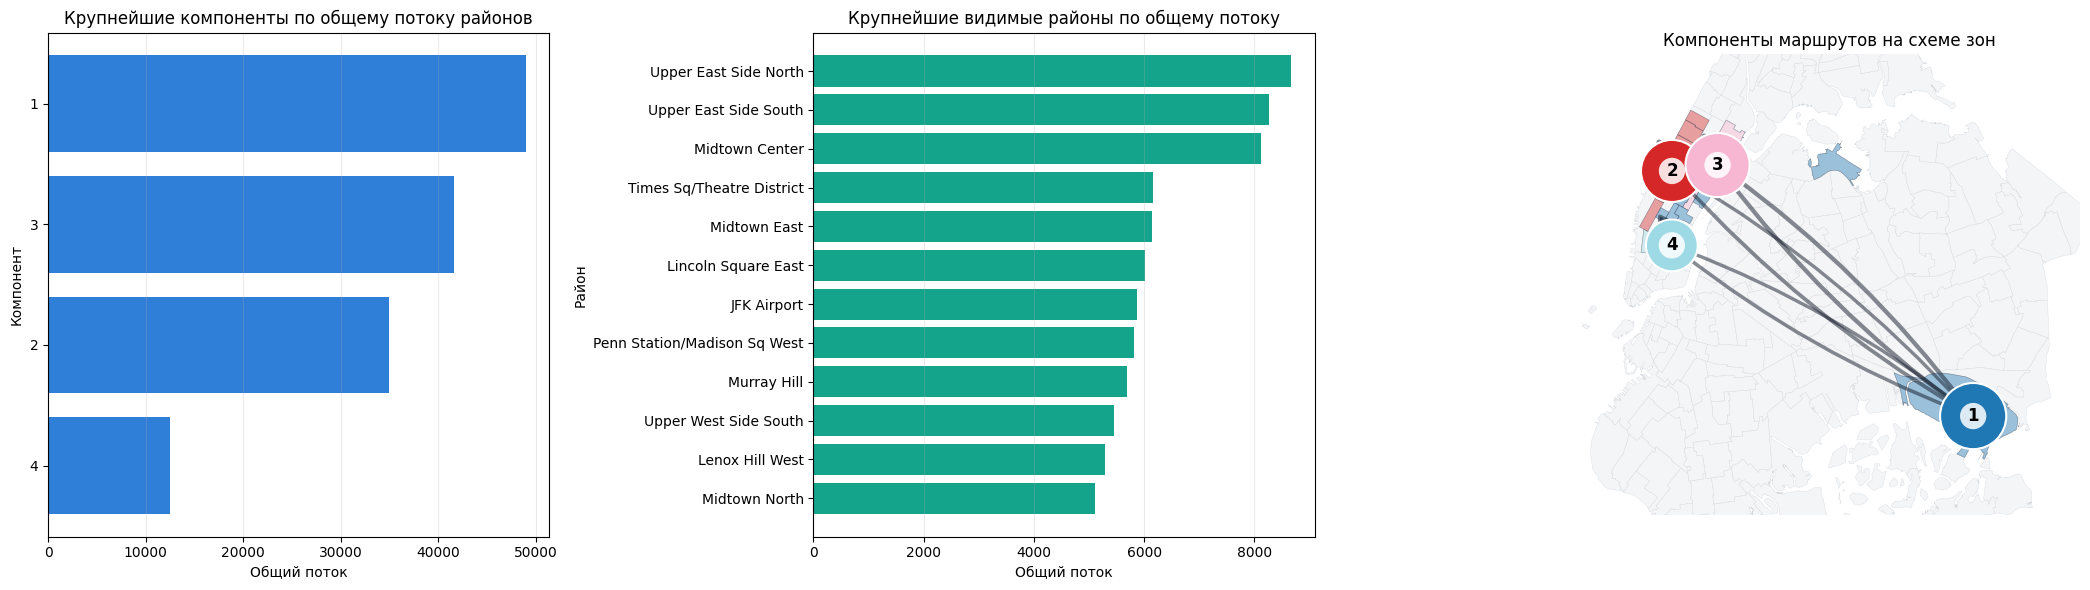

In [27]:
print("6. Сводные графики по компонентам и районам...")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

top_components = components_df.sort_values('component_total_flow', ascending=False).head(10).sort_values('component_total_flow')
axes[0].barh(top_components['component_id'].astype(str), top_components['component_total_flow'], color='#2f7ed8')
axes[0].set_title('Крупнейшие компоненты по общему потоку районов')
axes[0].set_xlabel('Общий поток')
axes[0].set_ylabel('Компонент')
axes[0].grid(axis='x', alpha=0.25)

zone_names_for_plot = taxi_zones_gdf.set_index('LocationID')['zone'].to_dict()
plot_nodes = nodes_df.copy()
plot_nodes['LocationID'] = plot_nodes['LocationID'].astype(int)
plot_nodes['zone_name'] = plot_nodes['LocationID'].map(zone_names_for_plot)
plot_nodes['zone_name'] = plot_nodes['zone_name'].fillna(plot_nodes['LocationID'].map(lambda zone_id: f'Район {zone_id}'))
top_nodes = plot_nodes[plot_nodes['LocationID'].isin(readable_graph.nodes)]
top_nodes = top_nodes.sort_values('total_flow', ascending=False).head(12).sort_values('total_flow')
axes[1].barh(top_nodes['zone_name'], top_nodes['total_flow'], color='#14a38b')
axes[1].set_title('Крупнейшие видимые районы по общему потоку')
axes[1].set_xlabel('Общий поток')
axes[1].set_ylabel('Район')
axes[1].grid(axis='x', alpha=0.25)

component_map_zones = taxi_zones_gdf[taxi_zones_gdf['LocationID'].isin(component_by_node)].copy()
component_map_zones['component_id'] = component_map_zones['LocationID'].map(component_by_node)
component_areas = component_map_zones.dissolve(by='component_id')
component_points = component_areas.representative_point()
component_pos = {
    int(component_id): (point.x, point.y)
    for component_id, point in component_points.items()
    if int(component_id) in component_graph.nodes()
}
component_node_sizes = [
    500 + float(components_df.loc[components_df['component_id'] == node, 'component_total_flow'].iloc[0]) ** 0.5 * 8
    if node in set(components_df['component_id']) else 700
    for node in component_graph.nodes()
]
component_edge_widths = [0.8 + np.log1p(component_graph[u][v]['weight']) / 3 for u, v in component_graph.edges()]
taxi_zones_gdf.plot(
    ax=axes[2],
    color='#f3f4f6',
    edgecolor='#d1d5db',
    linewidth=0.25,
    alpha=0.9,
)
component_map_zones.plot(
    ax=axes[2],
    column='component_id',
    categorical=True,
    cmap='tab20',
    edgecolor='#374151',
    linewidth=0.45,
    alpha=0.42,
)
nx.draw_networkx_edges(
    component_graph,
    component_pos,
    ax=axes[2],
    width=component_edge_widths,
    alpha=0.5,
    edge_color='#111827',
    arrows=True,
    arrowsize=14,
    connectionstyle='arc3,rad=0.08',
)
nx.draw_networkx_nodes(
    component_graph,
    component_pos,
    ax=axes[2],
    node_size=component_node_sizes,
    node_color=list(component_graph.nodes()),
    cmap='tab20',
    edgecolors='white',
    linewidths=1.5,
)
nx.draw_networkx_labels(
    component_graph,
    component_pos,
    ax=axes[2],
    font_size=12,
    font_weight='bold',
    bbox={'boxstyle': 'circle,pad=0.25', 'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85},
)
if not component_map_zones.empty:
    minx, miny, maxx, maxy = component_map_zones.total_bounds
    x_margin = max((maxx - minx) * 0.16, 3500)
    y_margin = max((maxy - miny) * 0.16, 3500)
    axes[2].set_xlim(minx - x_margin, maxx + x_margin)
    axes[2].set_ylim(miny - y_margin, maxy + y_margin)
axes[2].set_title('Компоненты маршрутов на схеме зон')
axes[2].set_axis_off()

plt.tight_layout()
plt.show()


In [28]:
import folium
import geopandas as gpd
from shapely.geometry import Point
from folium.plugins import PolyLineTextPath

print("7. Интерактивная прогнозная карта графа...")

# Подготовка геоданных
nodes_ids = list(pos.keys())
geometry = [Point(pos[nid][0], pos[nid][1]) for nid in nodes_ids]
gdf_pos = gpd.GeoDataFrame(geometry=geometry, index=nodes_ids, crs=taxi_zones_gdf.crs)
gdf_pos_degrees = gdf_pos.to_crs("EPSG:4326")
pos_corrected = {idx: (row.geometry.x, row.geometry.y) for idx, row in gdf_pos_degrees.iterrows()}

avg_lat = sum(coords[1] for coords in pos_corrected.values()) / len(pos_corrected)
avg_lon = sum(coords[0] for coords in pos_corrected.values()) / len(pos_corrected)
m = folium.Map(location=[avg_lat, avg_lon], zoom_start=11, tiles="cartodbpositron")

zone_names = taxi_zones_gdf.set_index("LocationID")["zone"].to_dict()
zone_boroughs = taxi_zones_gdf.set_index("LocationID")["borough"].to_dict()

# Относительные кандидаты для поиска файла прогнозов
prediction_candidates = [
    project_root / "ml_demand" / "reports" / "tables" / "next_hour_predictions_with_weather.csv",
    project_root / "reports" / "tables" / "next_hour_predictions_with_weather.csv",
]

prediction_path = next((path for path in prediction_candidates if path.exists()), None)
if prediction_path is None:
    # Показываем пользователю относительные пути в ошибке для переносимости
    checked_paths = "\n".join(f"- {p.relative_to(project_root)}" for p in prediction_candidates)
    raise FileNotFoundError(f"Не найден файл с прогнозами. Проверенные пути:\n{checked_paths}")

predictions = pd.read_csv(prediction_path)
predictions["PULocationID"] = predictions["PULocationID"].astype(int)

if "date_hour" in predictions.columns:
    prediction_time = pd.to_datetime(predictions["date_hour"], errors="coerce").dropna()
    prediction_label = "прогноз на следующий час"
    if not prediction_time.empty:
        prediction_label = f"прогноз на {prediction_time.min().strftime('%d.%m.%Y %H:%M')}"
else:
    prediction_label = "прогноз на следующий час"

prediction_by_zone = predictions.groupby("PULocationID", as_index=True).agg(
    predicted_demand=("predicted_demand", "mean"),
    predicted_revenue=("predicted_revenue", "mean"),
)

origin_totals = transit_routes.groupby("PULocationID")["route_trips"].sum()

# Отрисовка ребер графа
for u, v, data in readable_graph.edges(data=True):
    if u in pos_corrected and v in pos_corrected:
        start_coords = [pos_corrected[u][1], pos_corrected[u][0]]
        end_coords = [pos_corrected[v][1], pos_corrected[v][0]]

        historical_trips = float(data.get("weight", 1))
        avg_revenue = float(data.get("revenue", 0))
        predicted_origin_demand = float(prediction_by_zone.loc[u, "predicted_demand"]) if u in prediction_by_zone.index else 0.0
        route_share = historical_trips / float(origin_totals.get(u, historical_trips))
        expected_route_trips = predicted_origin_demand * route_share
        expected_route_revenue = expected_route_trips * avg_revenue

        u_name = zone_names.get(u, f"Неизвестная зона {u}")
        v_name = zone_names.get(v, f"Неизвестная зона {v}")
        line_weight = max(1.0, min(expected_route_trips / 2.0, 10.0))

        route_line = folium.PolyLine(
            locations=[start_coords, end_coords],
            color="#2f7ed8",
            weight=line_weight,
            opacity=0.45,
            tooltip=(
                f"<b>Маршрут:</b> {u_name} -> {v_name}<br>"
                f"<b>Ожидаемые поездки ({prediction_label}):</b> {expected_route_trips:,.2f}<br>"
                f"<b>Ожидаемая выручка маршрута:</b> ${expected_route_revenue:,.2f}<br>"
                f"<b>Средняя выручка за поездку:</b> ${avg_revenue:,.2f}<br>"
                f"<b>Доля этого направления в историческом потоке:</b> {route_share:.1%}"
            ),
        ).add_to(m)
        
        PolyLineTextPath(
            route_line,
            "     >     ",
            repeat=True,
            offset=7,
            attributes={"fill": "#174ea6", "font-weight": "bold", "font-size": "13"},
        ).add_to(m)

# Отрисовка узлов графа
max_predicted_demand = prediction_by_zone["predicted_demand"].max() if not prediction_by_zone.empty else 1.0
for node_id, (lon, lat) in pos_corrected.items():
    if node_id in prediction_by_zone.index:
        predicted_demand = float(prediction_by_zone.loc[node_id, "predicted_demand"])
        predicted_revenue = float(prediction_by_zone.loc[node_id, "predicted_revenue"])
    else:
        predicted_demand = 0.0
        predicted_revenue = 0.0

    zone_name = zone_names.get(node_id, f"Неизвестная зона {node_id}")
    borough = zone_boroughs.get(node_id, "")
    zone_title = f"{zone_name}, {borough}" if borough else zone_name
    radius = 4.0 + 12.0 * np.sqrt(predicted_demand / max_predicted_demand) if max_predicted_demand > 0 else 4.0

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color="#14a38b",
        fill=True,
        fill_color="#14a38b",
        fill_opacity=0.8,
        tooltip=(
            f"<b>Район:</b> {zone_title}<br>"
            f"<b>Предсказанный спрос ({prediction_label}):</b> {predicted_demand:,.2f} поездок<br>"
            f"<b>Предсказанная выручка:</b> ${predicted_revenue:,.2f}"
        ),
    ).add_to(m)

print(f"Используемый файл прогнозов: {prediction_path.relative_to(project_root)}")
print(f"Временная метка подписей: {prediction_label}")
m

7. Интерактивная прогнозная карта графа...
Используемый файл прогнозов: ml_demand\reports\tables\next_hour_predictions_with_weather.csv
Временная метка подписей: прогноз на 01.01.2025 00:00


8. Читаемый граф маршрутов на карте зон такси Нью-Йорка...


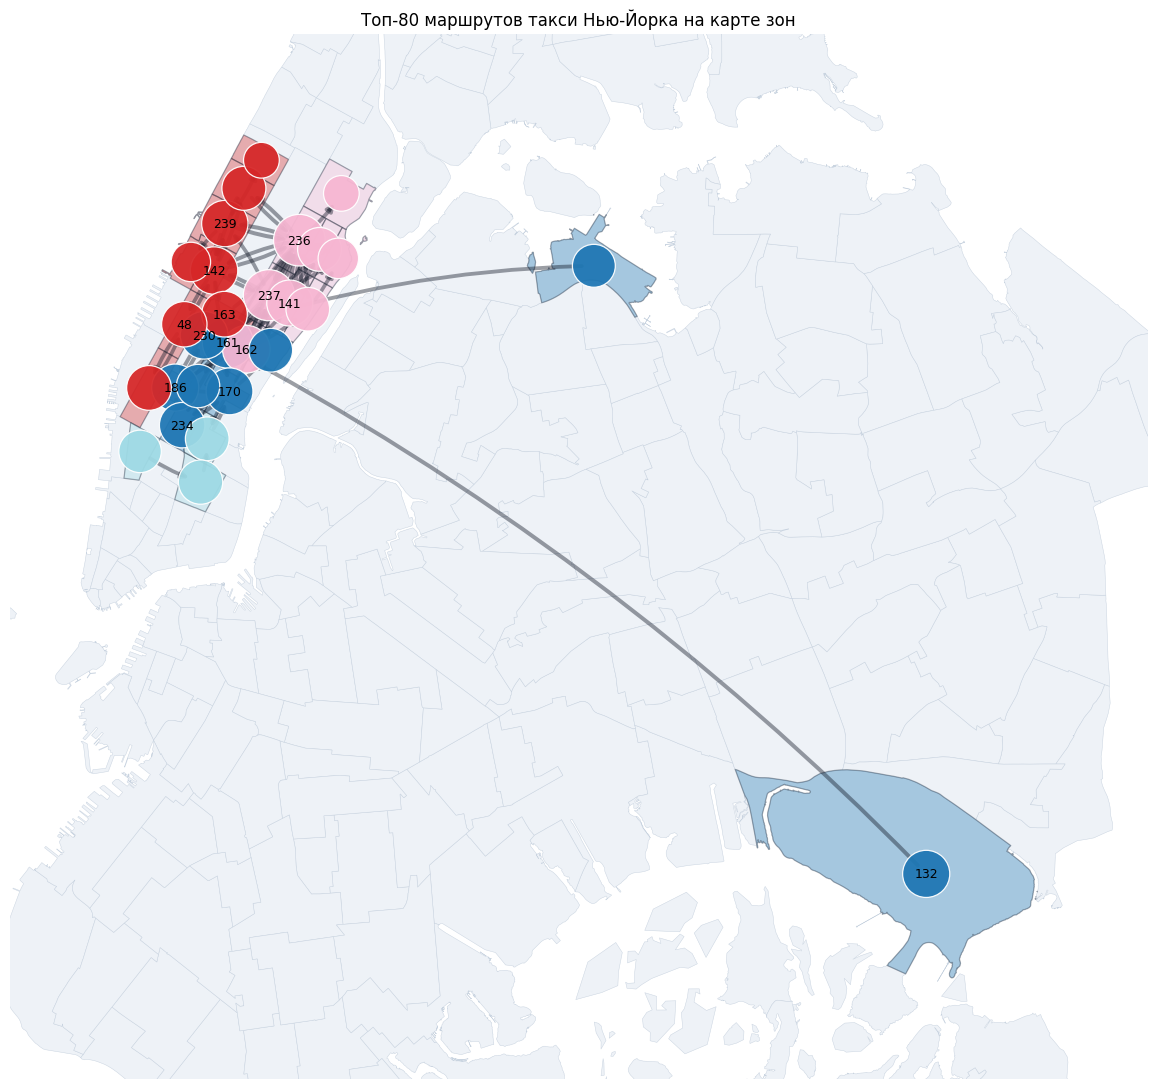

In [29]:
print("8. Читаемый граф маршрутов на карте зон такси Нью-Йорка...")

node_sizes = [80 + np.sqrt(node_metrics.loc[n, "total_flow"]) * 14 for n in readable_graph.nodes()]
node_colors = [component_by_node.get(n, 0) for n in readable_graph.nodes()]
edge_widths = [0.5 + np.log1p(readable_graph[u][v]["weight"]) / 2.3 for u, v in readable_graph.edges()]
visible_zone_ids = list(readable_graph.nodes())
visible_zones_gdf = taxi_zones_gdf[taxi_zones_gdf["LocationID"].isin(visible_zone_ids)].copy()
visible_zones_gdf["component_id"] = visible_zones_gdf["LocationID"].map(component_by_node)

fig, ax = plt.subplots(figsize=(12, 11))
taxi_zones_gdf.plot(
    ax=ax,
    color="#eef2f7",
    edgecolor="#c7d2df",
    linewidth=0.35,
    alpha=0.95,
)
visible_zones_gdf.plot(
    ax=ax,
    column="component_id",
    categorical=True,
    cmap="tab20",
    edgecolor="#1f2937",
    linewidth=0.9,
    alpha=0.35,
)

nx.draw_networkx_edges(
    readable_graph, pos,
    ax=ax,
    width=edge_widths,
    alpha=0.42,
    edge_color="#111827",
    arrows=True,
    arrowsize=10,
    connectionstyle="arc3,rad=0.08"
)
nx.draw_networkx_nodes(
    readable_graph, pos,
    ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="tab20",
    alpha=0.94,
    linewidths=0.9,
    edgecolors="white"
)
label_nodes = node_metrics.loc[list(readable_graph.nodes())].sort_values("total_flow", ascending=False).head(14).index
labels = {node: str(node) for node in readable_graph.nodes() if node in label_nodes}
nx.draw_networkx_labels(readable_graph, pos, labels=labels, ax=ax, font_size=9, font_color="black")

if not visible_zones_gdf.empty:
    minx, miny, maxx, maxy = visible_zones_gdf.total_bounds
    x_margin = max((maxx - minx) * 0.12, 2500)
    y_margin = max((maxy - miny) * 0.12, 2500)
    ax.set_xlim(minx - x_margin, maxx + x_margin)
    ax.set_ylim(miny - y_margin, maxy + y_margin)

ax.set_title(f"Топ-{READABLE_EDGE_LIMIT} маршрутов такси Нью-Йорка на карте зон")
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [30]:
print("9. Сохранение признаков графа...")

output_dir = project_root / "datasets"
output_dir.mkdir(exist_ok=True)

node_features_path = output_dir / "graph_node_features.parquet"
edge_features_path = output_dir / "graph_edge_features.parquet"
component_features_path = output_dir / "graph_route_components.parquet"
component_edges_path = output_dir / "graph_component_edges.parquet"

nodes_df.to_parquet(node_features_path, index=False)
route_stats.to_parquet(edge_features_path, index=False)
components_df.to_parquet(component_features_path, index=False)
component_edges.to_parquet(component_edges_path, index=False)

print("Файлы успешно сохранены (относительно корня проекта):")
print(f"- {node_features_path.relative_to(project_root)}")
print(f"- {edge_features_path.relative_to(project_root)}")
print(f"- {component_features_path.relative_to(project_root)}")
print(f"- {component_edges_path.relative_to(project_root)}")

9. Сохранение признаков графа...
Файлы успешно сохранены (относительно корня проекта):
- datasets\graph_node_features.parquet
- datasets\graph_edge_features.parquet
- datasets\graph_route_components.parquet
- datasets\graph_component_edges.parquet
